In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
import io
import tarfile
import gzip
from pathlib import Path
from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df_path = Path('../data/feat_matrix/Manipulate-Image-Features.pkl')
archive_path = df_path.with_name(df_path.stem + '.tar.gz')

if not os.path.exists(archive_path):
    with tarfile.open(archive_path, 'w:gz') as tar:
        tar.add(df_path, arcname=df_path.name)
else:
    with tarfile.open(archive_path, 'r:gz') as tar:
        pkl_members = [m for m in tar.getmembers()
                       if m.name.endswith('.pkl') and m.isfile()]
        
        if not pkl_members:
            raise ValueError('No .pkl file found in archive')
        
        member = pkl_members[0]
        print(f'Extracting: {member.name!r} size={member.size} bytes')

        if member.size == 0:
            raise ValueError('Pkl member has 0 bytes -- archive is corrupt, delete and re-run')
        
        f = tar.extractfile(member)
        if f is None:
            raise ValueError('Could not extract .pkl file')
            
        data = f.read()

    if data[:2] == b'\x1f\x8b':
        data = gzip.decompress(data)

    df = pickle.loads(data)

    if not isinstance(df, pd.DataFrame):
        raise TypeError(f'Expected DataFrame, got {type(df)}')

Extracting: 'Manipulate-Image-Features.pkl' size=7694127320 bytes


In [ ]:
class SBSS:
    def __init__(
            self,
            df: pd.DataFrame=None,
            non_pca_cols: np.ndarray=None,
            pca_components: int=50,
            random_state: int=0,
            image_id: str='image_id',
            label_col: str='label'
    ):

        self.df = df
        self.non_pca = non_pca_cols
        self.pca_components = pca_components
        self.random_state = random_state
        self.image_id = image_id
        self.label = label_col

    def image_fingerprint(
            self
    ):
    
        X = self.df.drop(self.non_pca, axis=1)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        pca = PCA(n_components=self.pca_components)
        X_pca = pca.fit_transform(X_scaled)
        df_pca = pd.DataFrame(X_pca, columns=[f'feat_{x}' for x in np.arange(self.pca_components)])
        for i, cols in enumerate(self.non_pca):
            df_pca.insert(i, cols, self.df[cols])
        
        feat_cols = df_pca.filter(like='feat_').columns
        C = df_pca.groupby(self.image_id).size()
        C = pd.DataFrame(C, columns=['Count'])
        D = df_pca.groupby(self.image_id)[self.label].sum() / C['Count']
        D = pd.DataFrame(D, columns=['Density'])
        F = df_pca.groupby(self.image_id)[feat_cols].mean()
        df_cluster = pd.concat([C, D, F], axis=1)
        
        return df_cluster.reset_index()
    
    def kmeans(
            self,
            n_clusters: int=5,
            plot: bool=True,
    ):

        df_cluster = self.image_fingerprint()
        X_cluster = df_cluster.drop([self.image_id], axis=1).to_numpy()
        
        # Fit K-Means Clustering Model
        km = KMeans(n_clusters=n_clusters, random_state=self.random_state)
        clusters = km.fit_predict(X_cluster)

        # Plotting K-Means Clustering
        if plot:
            plot_pca = PCA(n_components=2)
            X_plot = plot_pca.fit_transform(X_cluster)
            plt.scatter(X_plot[:, 0], X_plot[:, 1], c=clusters)
            plt.xlabel('PCA 1')
            plt.ylabel('PCA 2')
            plt.title('K-Means Clustering', size=27)
            plt.tight_layout()
            plt.show()

        return clusters
    
    def train_test_split(
            self,
            test_size: np.float32=0.2,
            plot_cluster: bool=False,
    ):
        clusters = self.kmeans(plot=plot_cluster)

        df_split = pd.DataFrame(clusters, columns=['cluster_id']).reset_index(names=['image_id'])
        df_split['train?'] = np.zeros((len(df_split)), dtype=np.int8)
        
        for i in range(df_split['cluster_id'].nunique()):
            train_idx = df_split[df_split['cluster_id'] == i][self.image_id].sample(frac=1-test_size, random_state=self.random_state)
            df_split.loc[train_idx, 'train?'] = 1

        # Train 'n Test indices split
        train_idx = df_split[self.image_id][df_split['train?'] == 1].to_numpy()
        test_idx = df_split[self.image_id][df_split['train?'] == 0].to_numpy()

        # Train 'n Test data split
        feat_cols = self.df.filter(like='feat_').columns
        train_data = self.df[self.df[self.image_id].isin(train_idx)]
        X_train = train_data[feat_cols].values
        y_train = train_data[self.label].values
        test_data = self.df[self.df[self.image_id].isin(test_idx)]
        X_test = test_data[feat_cols].values
        y_test = test_data[self.label].values

        return X_train, X_test, y_train, y_test

In [21]:
sbss = SBSS(
    df,
    non_pca_cols=['image_id', 'label'],
    random_state=21
)

**Elbow Method --> n_clusters=5**

In [5]:
df_cluster = sbss.image_fingerprint()

In [6]:
df_cluster

,image_id,Count,Density,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,...,feat_40,feat_41,feat_42,feat_43,feat_44,feat_45,feat_46,feat_47,feat_48,feat_49
0,0,4599,0.000000,-0.118081,1.876262,-0.257988,1.426161,-0.186739,0.184968,0.212486,...,0.116124,0.191660,-0.239708,0.083608,0.078063,0.046529,-0.162336,-0.242186,-0.022799,-0.005722
1,1,7735,0.013963,3.490411,-1.960486,-2.483164,0.712653,-1.029109,-0.011452,-0.057340,...,0.054421,0.253031,0.067558,0.213067,-0.106822,-0.453300,-0.397641,-0.218560,0.036571,-0.289714
2,2,2961,0.000000,1.789985,-1.024415,-0.661756,-0.389339,-0.098856,-0.103099,0.521002,...,-0.026724,0.050073,-0.135909,0.065142,-0.043724,-0.050189,0.020461,-0.007269,0.075973,0.129293
3,3,2961,0.101317,0.985979,-0.616637,-0.514399,-0.551069,0.065855,-0.105529,0.579003,...,-0.045106,0.051423,-0.099067,0.075475,-0.019446,-0.060446,-0.026431,-0.001661,0.047767,0.054498
4,4,2961,0.026005,1.637814,-0.984858,-0.736189,-0.398807,-0.105437,-0.034298,0.562535,...,-0.070092,0.066180,-0.147327,0.054785,-0.039998,-0.059091,0.022981,0.000041,0.056053,0.136136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2419,2419,567,0.324515,-3.348647,-0.310908,-0.511890,-1.654310,0.201482,0.449324,-0.321918,...,-0.008277,-0.075918,0.088974,-0.001857,0.177600,0.099246,0.058845,0.058765,0.124777,0.042437
2420,2420,323,0.000000,-3.685912,-0.171974,-0.282703,-1.831306,-0.559586,-0.038326,0.161678,...,-0.050285,-0.216357,-0.102624,-0.046318,0.011251,-0.044737,-0.161711,-0.023124,-0.013659,-0.006594
2421,2421,323,0.383901,-5.363809,-1.555300,0.449784,-2.307540,-1.174826,0.330041,0.120886,...,0.058178,0.043455,-0.158430,0.010557,0.084252,-0.059577,0.018398,-0.000695,-0.104316,-0.055864
2422,2422,713,0.000000,0.713086,0.392479,1.467541,0.009925,-0.234422,0.254441,-0.102983,...,-0.140900,-0.024284,0.048039,-0.139262,-0.008569,0.023503,-0.029234,-0.103971,0.020196,0.059373


In [7]:
X_cluster = df_cluster.iloc[:, 1:].to_numpy()
kmeans = KMeans(n_clusters=5, random_state=21)
clusters = kmeans.fit_predict(X_cluster)

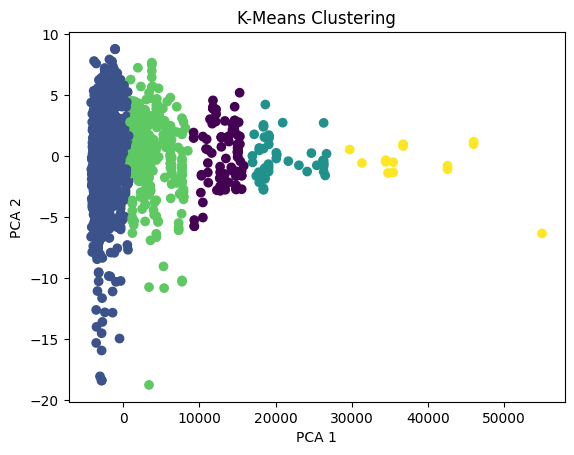

In [8]:
plot_pca = PCA(n_components=2)
X_plot = plot_pca.fit_transform(X_cluster)

plt.scatter(X_plot[:, 0], X_plot[:, 1], c=clusters)
# plt.scatter(X_cluster[:, 0], X_cluster[:, 1], c=clusters)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('K-Means Clustering')
plt.show()

In [22]:
X_train, X_test, y_train, y_test = sbss.train_test_split(test_size=0.2)
len(X_train) / (len(X_train) + len(X_test))

0.8032312914212861

In [25]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8477589, 90), (2076767, 90), (8477589,), (2076767,))